# COM7019 Assignment - Stock Price Prediction
**Student ID:** 25199053

This notebook is my main code for Task 1. I compare **LSTM**, **GRU**, and a **CNN-LSTM hybrid** on the stock price dataset from the brief.


In [1]:
# ============================================================
# STEP 1: Import libraries and set basic options
# ============================================================
# Libraries used (all covered in the module workshops):
#   - pandas     : reading the CSV file and building result tables
#   - numpy      : maths on arrays (windows, error calculations)
#   - matplotlib : the figures for the report, including the
#                  architecture diagrams I draw by hand in STEP 8
#   - tensorflow / keras : building and training the neural networks

import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from tensorflow import keras

# Neural network training is random by nature: the starting weights
# are random and the training batches are shuffled. Fixing a seed
# makes each run give (almost) the same numbers, so every value I
# quote in the report can be checked by re-running this notebook.
# I used my student ID as the seed value.
SEED = 25199053
keras.utils.set_random_seed(SEED)

# Everything this notebook saves (figures, tables, model summaries)
# goes into one folder, so it is easy to find for the report appendix.
OUTPUT_FOLDER = "outputs_student"
os.makedirs(OUTPUT_FOLDER + "/figures", exist_ok=True)
os.makedirs(OUTPUT_FOLDER + "/tables", exist_ok=True)
os.makedirs(OUTPUT_FOLDER + "/models", exist_ok=True)


In [26]:
# ============================================================
# STEP 2: Load the dataset
# ============================================================
# The brief says to use Stock_Price_Data_[3921].csv and nothing else.
# I upload it into Colab next to this notebook, so a plain filename
# is enough to read it.

df = pd.read_csv("Stock_Price_Data_[3921].csv")

# The Date column is read as plain text, so I convert it to real
# datetime values. I need proper dates for sorting checks and for
# the x-axis of the plots.
df["Date"] = pd.to_datetime(df["Date"])

print("Number of rows:", len(df))
print("Columns:", list(df.columns))
df.head()


Number of rows: 9909
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [3]:
# ============================================================
# STEP 3: Check the data before modelling
# ============================================================
# I always inspect the data before modelling. Two problems in
# particular would silently break a time-series experiment:
#   - missing values inside the series (gaps in the windows)
#   - duplicated or out-of-order dates (the chronological split
#     in STEP 4 assumes one row per day, oldest first)

print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate dates:", df["Date"].duplicated().sum())

# Also make sure the rows really are in date order before I split.
is_sorted = df["Date"].is_monotonic_increasing
print("Dates already sorted oldest-to-newest:", is_sorted)

# I predict Adjusted Close rather than raw Close. Adj Close corrects
# the price for dividends, so it reflects what an investor actually
# earned. For this dataset the two columns are very similar, but
# Adj Close is the more honest target (Chollet, 2025; we used
# similar reasoning in the module).
TARGET_COLUMN = "Adj Close"
prices = df[TARGET_COLUMN].values.astype(float)
dates = df["Date"].values

# The huge min-to-max range below (a few cents to hundreds of dollars)
# is exactly why I cannot use a simple MinMax scaler later; see the
# markdown note before STEP 5.
print("\nMin price:", prices.min(), "| Max price:", prices.max())


Date range: 1980-12-12 to 2020-04-01

Missing values per column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Duplicate dates: 0
Dates already sorted oldest-to-newest: True

Min price: 0.1556382328271865 | Max price: 327.20001220703125


Training rows  : 0 to 6935 → ends 2008-06-10
Validation rows: 6936 to 8421 → ends 2014-05-06
Test rows      : 8422 to 9908 → ends 2020-04-01


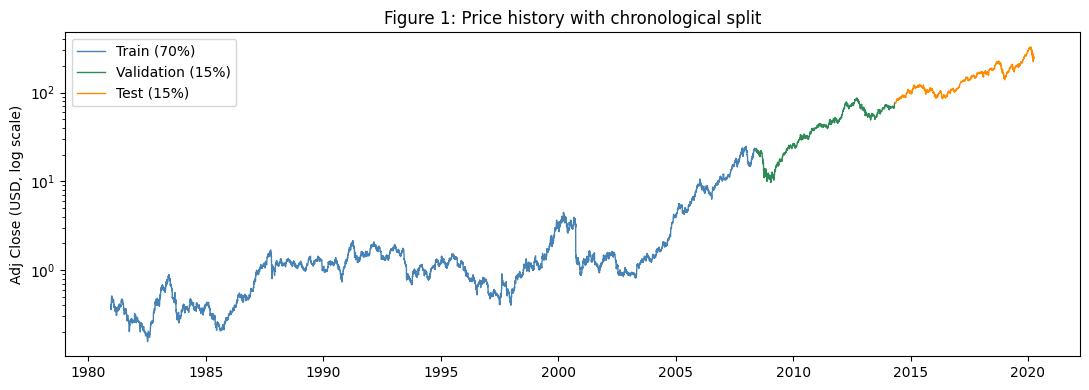

In [4]:
# ============================================================
# STEP 4: Train / validation / test split (70% / 15% / 15%)
# ============================================================
# IMPORTANT: for time series we must NOT shuffle before splitting.
# A random split would let the model train on days that come AFTER
# some of the test days. That is data leakage, and the test score
# would look better than the model deserves.
#
# So I split chronologically:
#   - train      = oldest 70% of days   (the model learns from these)
#   - validation = next 15%             (used to tune and compare models)
#   - test       = most recent 15%      (touched ONCE, for final scores)
# This mimics real life: predict the future from the past only.

n_total = len(df)
train_end = int(n_total * 0.70)   # index where training ends
val_end = int(n_total * 0.85)     # index where validation ends

print("Training rows  : 0 to", train_end - 1, "→ ends", df["Date"].iloc[train_end - 1].date())
print("Validation rows:", train_end, "to", val_end - 1, "→ ends", df["Date"].iloc[val_end - 1].date())
print("Test rows      :", val_end, "to", n_total - 1, "→ ends", df["Date"].iloc[-1].date())

# Plot the full price history, one colour-coded segment per split
plt.figure(figsize=(11, 4))
plt.plot(dates[:train_end], prices[:train_end], color="steelblue", linewidth=1, label="Train (70%)")
plt.plot(dates[train_end:val_end], prices[train_end:val_end], color="seagreen", linewidth=1, label="Validation (15%)")
plt.plot(dates[val_end:], prices[val_end:], color="darkorange", linewidth=1, label="Test (15%)")
plt.yscale("log")
plt.ylabel("Adj Close (USD, log scale)")
plt.title("Figure 1: Price history with chronological split")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + "/figures/fig1_price_history.png")
plt.show()


## How I prepare the input windows

Recurrent networks need **sequences** of past prices as input, not single days. So I slide a fixed-length window along the series: the window is the input, and the day right after the window is the target.

- I use a **60-day window** as the default (roughly one quarter of trading days). I also test a 30-day window later as an experiment.
- **Why not a normal MinMax scaler?** The stock grew enormously over 40 years: training prices are under \$25 but test prices go above \$300. A scaler fitted on training data (the only correct way; fitting on all data would leak test information) would map every test price outside the range it was fitted on, and the model would see input values it never saw in training.
- **My solution: per-window normalisation.** Inside each window I express every price as a *percentage change relative to the last day of that window*. A window from 1985 and a window from 2019 then look similar to the model (e.g. "prices drifted up about 2% over the window"), even though the dollar levels differ by a factor of 100.
- The target is the **next day's relative change** measured from the same reference day. After predicting, I multiply back by that day's actual price to get a dollar prediction, so RMSE and MAE are in USD and easy to interpret.


In [5]:
# ============================================================
# STEP 5: Build sliding windows
# ============================================================
# One sample = 60 consecutive days of prices (the input window)
# plus the day that follows them (the target).
# Example with the first sample:
#   input  = days 0..59, each expressed as % change vs day 59
#   target = day 60, also as % change vs day 59
# Then the window slides forward one day and repeats.

WINDOW_SIZE = 60  # number of past days used as input

X_list = []       # input sequences
y_list = []       # targets (next day's relative change)
base_list = []    # last price of each window, the "reference price"
                  # I need it later to convert predictions back to USD

for i in range(len(prices) - WINDOW_SIZE):
    window_prices = prices[i : i + WINDOW_SIZE]

    # The last day of the window is the reference price.
    # Dividing by it turns dollar prices into relative values,
    # e.g. 0.02 means "2% above the reference day".
    last_price = window_prices[-1]
    x_window = (window_prices / last_price) - 1.0

    # The target is the NEXT day's price, measured the same way.
    next_price = prices[i + WINDOW_SIZE]
    y_value = (next_price / last_price) - 1.0

    X_list.append(x_window)
    y_list.append(y_value)
    base_list.append(last_price)

# Keras expects inputs shaped (samples, timesteps, features).
# We have one feature per day (the normalised price), so the
# feature dimension is 1.
X = np.array(X_list, dtype="float32").reshape(-1, WINDOW_SIZE, 1)
y = np.array(y_list, dtype="float32")
base = np.array(base_list, dtype="float64")

print("Total samples:", len(y))
print("X shape:", X.shape, " (samples, timesteps, features)")

# Sanity check: the last value of every window should be exactly 0
# (each day divided by itself, minus 1). If not, the windowing is wrong.
print("Last value of first window (should be 0.0):", X[0, -1, 0])


Total samples: 9849
X shape: (9849, 60, 1)  (samples, timesteps, features)
Last value of first window (should be 0.0): 0.0


In [6]:
# ============================================================
# STEP 6: Assign each sample to train / val / test
# ============================================================
# Each sample is dated by its TARGET day (the day being predicted),
# which sits at index (WINDOW_SIZE + i) in the original price series.
# I compare that index against the split boundaries from STEP 4.
#
# Using the target day (not the window start) matters: a sample whose
# target falls in the validation period may still have some training-era
# days inside its input window, which is fine; in real forecasting
# you always know the recent past. What must never happen is a TARGET
# from the future ending up in the training set.

train_mask = []
val_mask = []
test_mask = []

for i in range(len(y)):
    target_day_index = WINDOW_SIZE + i
    if target_day_index < train_end:
        train_mask.append(True)
        val_mask.append(False)
        test_mask.append(False)
    elif target_day_index < val_end:
        train_mask.append(False)
        val_mask.append(True)
        test_mask.append(False)
    else:
        train_mask.append(False)
        val_mask.append(False)
        test_mask.append(True)

# Convert to numpy arrays so they can be used for fancy indexing below
train_mask = np.array(train_mask)
val_mask = np.array(val_mask)
test_mask = np.array(test_mask)

X_train, y_train, base_train = X[train_mask], y[train_mask], base[train_mask]
X_val, y_val, base_val = X[val_mask], y[val_mask], base[val_mask]
X_test, y_test, base_test = X[test_mask], y[test_mask], base[test_mask]

print("Train samples:", len(y_train))
print("Val samples  :", len(y_val))
print("Test samples :", len(y_test))


Train samples: 6876
Val samples  : 1486
Test samples : 1487


In [7]:
# ============================================================
# STEP 7: Naive baseline, "tomorrow's price = today's price"
# ============================================================
# Before building any neural network I set up the simplest possible
# forecast, called the persistence baseline: just predict that
# tomorrow's price equals today's price.
#
# This gives the neural networks something meaningful to beat.
# Stock prices are close to a random walk, so persistence is
# surprisingly hard to beat; if a complex model cannot do better
# than this one-line rule, the model is not adding real value.

# First convert the relative test targets back to dollar prices,
# by reversing the normalisation from STEP 5:
#   relative change + 1, times the reference price = actual price
actual_test_usd = (y_test + 1.0) * base_test

# The persistence "prediction" is simply the reference price itself
# (the last known price before the day being predicted).
predicted_persistence = base_test

# Three standard regression metrics, all in interpretable units:
#   RMSE: root mean squared error (USD); punishes big misses hardest
#   MAE : mean absolute error (USD); the typical miss size
#   MAPE: mean absolute percentage error; scale-free, good for
#          comparing errors on cheap 1980s prices vs expensive 2020 ones
errors = predicted_persistence - actual_test_usd
baseline_rmse = np.sqrt(np.mean(errors ** 2))
baseline_mae = np.mean(np.abs(errors))
baseline_mape = np.mean(np.abs(errors / actual_test_usd)) * 100

print("Baseline (persistence) on TEST set:")
print("  RMSE :", round(baseline_rmse, 4))
print("  MAE  :", round(baseline_mae, 4))
print("  MAPE :", round(baseline_mape, 3), "%")

# I will store all model results in this list and build a table at the end
all_results = []
all_results.append({
    "Model": "Baseline (persistence)",
    "Test RMSE": baseline_rmse,
    "Test MAE": baseline_mae,
    "Test MAPE %": baseline_mape,
})


Baseline (persistence) on TEST set:
  RMSE : 3.238
  MAE  : 1.8269
  MAPE : 1.159 %


## Neural network models

I build three types of model as required by the brief, plus my CNN-LSTM extension:

| Model | Layers (summary) | Why |
|-------|------------------|-----|
| LSTM | 1 or 2 LSTM layers + Dropout + Dense(1) | Required by brief; good for long sequences |
| GRU | 1 or 2 GRU layers + Dropout + Dense(1) | Required by brief; fewer parameters than LSTM |
| CNN-LSTM | Conv1D + MaxPool + LSTM + Dropout + Dense(1) | My extension: CNN finds short patterns, LSTM finds longer trends |

**Activations:** LSTM/GRU use their built-in gate activations (sigmoid for the gates, tanh for the cell state); these are part of the layer design and should not be changed. Conv1D uses ReLU, the standard choice for convolutions. The final Dense layer has **no activation** (linear output) because we are predicting a continuous value that can be positive or negative; squashing it with sigmoid or tanh would limit the range the model can predict.

**Training settings (identical for every model unless an experiment says otherwise):**
- Loss: MSE, the standard regression loss; matches RMSE, the headline metric
- Optimiser: Adam with learning rate 0.001 (Keras default; a lower rate is tested later)
- Early stopping: stop when validation loss has not improved for 5 epochs, and restore the best weights seen; this prevents overfitting and removes the need to guess the "right" number of epochs
- Dropout: 0.2 after each recurrent layer (I also retrain without dropout to measure its effect)
- Max epochs: 40, batch size: 64

Keeping the settings fixed matters for fairness: if two models differ in accuracy, I want to be able to say it is because of the *architecture*, not because one got better training conditions.


In [8]:
# ============================================================
# STEP 8: Helper functions for training and evaluation
# ============================================================
# Every model in this notebook is trained and scored the exact same
# way, so I wrote the shared part once as two small functions
# (similar to what we did in the Week 7 workshop). This guarantees
# the comparison between models is fair: same callbacks, same
# epochs, same metrics for everyone.

# Shared training settings (see the markdown cell above for reasoning)
EPOCHS = 40
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.2

# I keep each model's loss-per-epoch history here so I can plot
# the training curves at the end (Figure 2).
training_histories = {}


# I first tried Keras' built-in keras.utils.plot_model, but it only
# draws plain black-and-white boxes and needs graphviz installed
# separately. I also tried the visualkeras library: its "layered" view
# crashed on this TensorFlow version, and its "graph" view draws every
# layer as a generic fully-connected diagram, which is simply wrong for
# a Conv1D or LSTM layer. So I draw the diagram myself with matplotlib
# shapes instead. This needs no extra install, and I get to show
# exactly what matters: each box coloured by layer type (using the same
# colours as my loss and prediction plots later on, so the report is
# visually consistent), labelled with its key setting and output shape,
# with a loop arrow on LSTM/GRU boxes to show they process the window
# step by step. That loop is the one thing neither ready-made tool drew.

# Same colour convention as the loss-curve and prediction plots further
# down: LSTM = steelblue, GRU = seagreen, the hybrid's CNN front-end =
# darkorange. Dropout and Dense stay neutral grey/charcoal.
ARCHITECTURE_COLOURS = {
    "InputLayer": "#E5E5E5",
    "Conv1D": "darkorange",
    "MaxPooling1D": "#F8CBA6",
    "LSTM": "steelblue",
    "GRU": "seagreen",
    "Dropout": "#C9C9C9",
    "Dense": "#4D4D4D",
}
LIGHT_BOXES = {"InputLayer", "MaxPooling1D", "Dropout"}  # need dark text on these
RECURRENT_LAYERS = {"LSTM", "GRU"}


def layer_summary(layer):
    """A short label of the layer's key setting, e.g. '64 units'."""
    cfg = layer.get_config()
    kind = type(layer).__name__
    if kind in ("LSTM", "GRU"):
        return f"{cfg['units']} units"
    if kind == "Dense":
        return f"{cfg['units']} unit{'s' if cfg['units'] != 1 else ''}, {cfg.get('activation', 'linear')}"
    if kind == "Conv1D":
        return f"{cfg['filters']} filters, k={cfg['kernel_size'][0]}, {cfg.get('activation')}"
    if kind == "MaxPooling1D":
        return f"pool={cfg['pool_size'][0]}"
    if kind == "Dropout":
        return f"rate={cfg['rate']}"
    return ""


def shape_str(shape):
    """Turns a Keras shape, e.g. (None, 60, 1), into a plain string."""
    return "(" + ", ".join("None" if d is None else str(d) for d in shape) + ")"


def show_architecture(model, filename):
    """Draw, save, and display a left-to-right diagram of the model's layers."""
    boxes = [("Input", "", shape_str(model.inputs[0].shape),
              ARCHITECTURE_COLOURS["InputLayer"], False)]
    for layer in model.layers:
        kind = type(layer).__name__
        colour = ARCHITECTURE_COLOURS.get(kind, "#CCCCCC")
        boxes.append((kind, layer_summary(layer), shape_str(layer.output.shape),
                      colour, kind in RECURRENT_LAYERS))

    box_w, box_h, gap = 2.1, 1.3, 0.9
    fig_w = len(boxes) * box_w + (len(boxes) - 1) * gap + 1
    fig_h = 3.5

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.set_xlim(0, fig_w)
    ax.set_ylim(0, fig_h)
    ax.axis("off")

    x = 0.5
    y = (fig_h - box_h) / 2 - 0.15
    centres = []

    for name, subtitle, shape_text, colour, is_recurrent in boxes:
        text_colour = "black" if name in LIGHT_BOXES or name == "Input" else "white"

        box = FancyBboxPatch((x, y), box_w, box_h,
                              boxstyle="round,pad=0.02,rounding_size=0.12",
                              linewidth=1.3, edgecolor="black", facecolor=colour)
        ax.add_patch(box)
        cx, cy = x + box_w / 2, y + box_h / 2
        centres.append((cx, cy))

        ax.text(cx, cy + 0.34, name, ha="center", va="center",
                fontsize=11, fontweight="bold", color=text_colour)
        if subtitle:
            ax.text(cx, cy + 0.02, subtitle, ha="center", va="center",
                    fontsize=8.3, color=text_colour)
        ax.text(cx, cy - 0.34, shape_text, ha="center", va="center",
                fontsize=8, style="italic", color=text_colour)

        if is_recurrent:
            # The classic "loops back into itself" symbol for a
            # recurrent layer: it reads the window one day at a time,
            # carrying its own output forward to the next day.
            loop = FancyArrowPatch(
                (x + box_w * 0.78, y + box_h), (x + box_w * 0.22, y + box_h),
                connectionstyle="arc3,rad=1.4",
                arrowstyle="-|>", mutation_scale=14, linewidth=1.3, color="black")
            ax.add_patch(loop)
            ax.text(cx, y + box_h + 0.5, "processes window\nstep by step",
                    ha="center", va="bottom", fontsize=6.6, color="dimgray")

        x += box_w + gap

    # Arrows showing the flow of data from one layer to the next
    for (cx1, cy1), (cx2, cy2) in zip(centres[:-1], centres[1:]):
        ax.annotate("", xy=(cx2 - box_w / 2, cy2), xytext=(cx1 + box_w / 2, cy1),
                    arrowprops=dict(arrowstyle="-|>", linewidth=1.4, color="black"))

    ax.set_title(model.name, fontsize=13, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.savefig(OUTPUT_FOLDER + "/figures/" + filename, dpi=150, bbox_inches="tight")
    plt.show()


def train_model(model, model_name, X_tr, y_tr, X_va, y_va):
    """Train one compiled model with early stopping.

    The training and validation data are passed in explicitly, so the
    function has no hidden dependencies, so I can reuse it unchanged for
    the 30-day-window experiment later. Returns the trained model and
    the training time in seconds.
    """
    # Reset the seed before every model so each one starts from the
    # same random state; otherwise the training order would affect
    # the results and the comparison would not be fair.
    keras.utils.set_random_seed(SEED)

    # Early stopping watches the validation loss. If it has not
    # improved for 5 epochs in a row, training stops and the weights
    # roll back to the best epoch. This is one of the generalisation
    # techniques required by the brief.
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )

    print("\n--- Training:", model_name, "---")
    start_time = time.time()

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0,   # keep the notebook output clean; results are printed below
    )

    elapsed = time.time() - start_time
    training_histories[model_name] = history.history
    print("Finished in", round(elapsed, 1), "seconds,",
          len(history.history["loss"]), "epochs")

    return model, elapsed


def evaluate_model(model, model_name, elapsed_seconds, X_te, y_te, base_te):
    """Score one trained model on a test set.

    Predictions are converted from relative changes back to dollars,
    so RMSE and MAE are in USD. The row is added to `all_results`
    for the final comparison table.
    """
    # The model outputs relative changes (e.g. 0.01 = +1%)...
    y_pred_rel = model.predict(X_te, verbose=0).flatten()

    # ...so multiply by each window's reference price to get dollars.
    y_pred_usd = (y_pred_rel + 1.0) * base_te
    y_true_usd = (y_te + 1.0) * base_te

    # Same three metrics as the baseline in STEP 7, so every model
    # is directly comparable with persistence.
    err = y_pred_usd - y_true_usd
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    mape = float(np.mean(np.abs(err / y_true_usd)) * 100)

    print(model_name, "→ Test RMSE:", round(rmse, 4), "| MAE:", round(mae, 4))

    all_results.append({
        "Model": model_name,
        "Test RMSE": rmse,
        "Test MAE": mae,
        "Test MAPE %": mape,
        "Parameters": model.count_params(),
        "Train time (s)": round(elapsed_seconds, 1),
    })

    return rmse


Model: "LSTM_64_d02"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

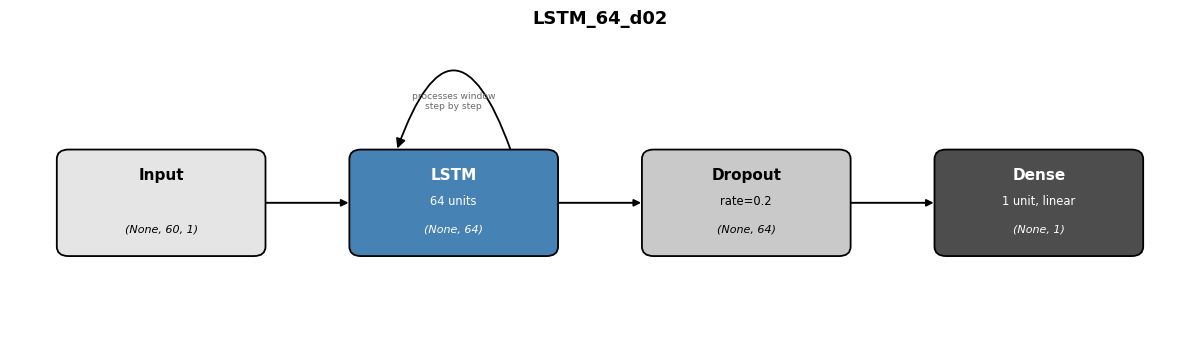


--- Training: LSTM_64_d02 ---
Finished in 18.8 seconds, 18 epochs
LSTM_64_d02 → Test RMSE: 3.2486 | MAE: 1.8281


3.248560759197396

In [9]:
# ============================================================
# STEP 9: Model 1, LSTM with 64 units (dropout 0.2)
# ============================================================
# My starting point: the simplest LSTM that can do the job.
# Layer by layer:
#   Input   : one window of 60 days, 1 feature per day
#   LSTM    : 64 units read the window day by day and keep a memory
#             of what they have seen; the output is the final state
#   Dropout : randomly switches off 20% of the LSTM outputs during
#             training, so the Dense layer cannot rely on any single
#             unit (helps generalisation)
#   Dense(1): one linear output: the predicted relative change
# 64 units is a sensible middle ground for a single-feature input:
# big enough to learn patterns, small enough to train quickly.

model_lstm_64 = keras.Sequential(name="LSTM_64_d02")
model_lstm_64.add(keras.layers.Input(shape=(WINDOW_SIZE, 1)))
model_lstm_64.add(keras.layers.LSTM(64))
model_lstm_64.add(keras.layers.Dropout(DROPOUT_RATE))
model_lstm_64.add(keras.layers.Dense(1))  # linear output for regression

model_lstm_64.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"],
)

# Print the layer table once, so the report shows what an LSTM
# model looks like inside (parameter counts per layer), plus a
# diagram of the same architecture for the report figures.
model_lstm_64.summary()
show_architecture(model_lstm_64, "arch_LSTM_64_d02.png")

model_lstm_64, t = train_model(model_lstm_64, "LSTM_64_d02",
                               X_train, y_train, X_val, y_val)
evaluate_model(model_lstm_64, "LSTM_64_d02", t, X_test, y_test, base_test)


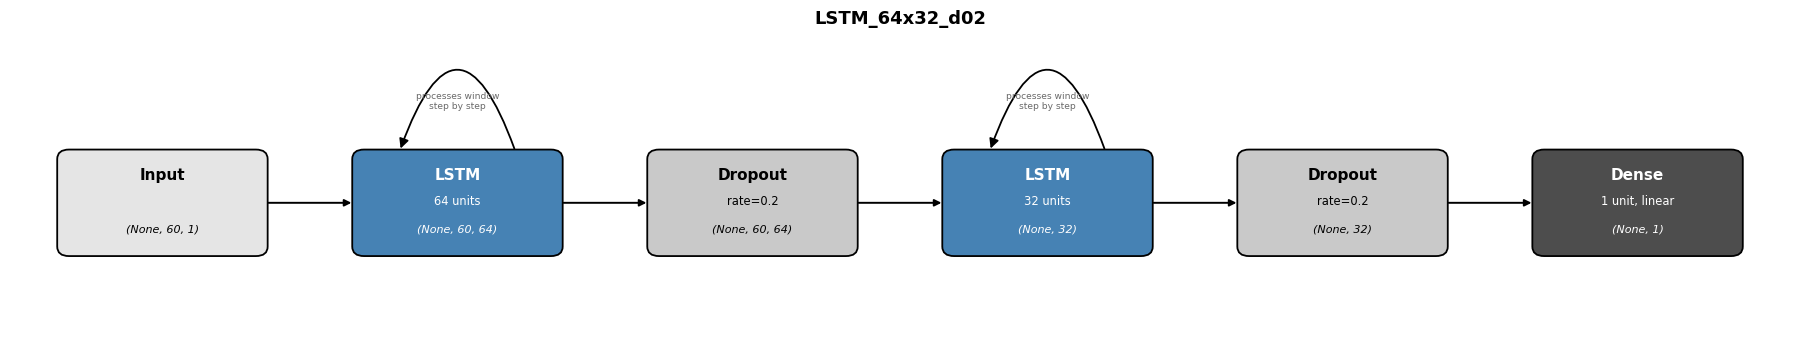


--- Training: LSTM_64x32_d02 ---
Finished in 20.0 seconds, 15 epochs
LSTM_64x32_d02 → Test RMSE: 3.2427 | MAE: 1.8252


3.2427390721421316

In [10]:
# ============================================================
# STEP 10: Model 2, LSTM with 64 then 32 units (two layers)
# ============================================================
# A deeper version of Model 1, to test whether stacking a second
# LSTM layer helps. The idea: the first layer learns simple
# day-to-day patterns, the second combines them into longer ones.
#
# Technical detail: an LSTM normally outputs only its FINAL state
# (one vector). To stack another LSTM on top, the first one must
# output its state at EVERY timestep; that is what
# return_sequences=True does. The second LSTM then outputs only
# its final state as usual, which goes to the Dense layer.

model_lstm_64_32 = keras.Sequential(name="LSTM_64x32_d02")
model_lstm_64_32.add(keras.layers.Input(shape=(WINDOW_SIZE, 1)))
model_lstm_64_32.add(keras.layers.LSTM(64, return_sequences=True))  # pass full sequence to next layer
model_lstm_64_32.add(keras.layers.Dropout(DROPOUT_RATE))
model_lstm_64_32.add(keras.layers.LSTM(32))   # second layer: final state only
model_lstm_64_32.add(keras.layers.Dropout(DROPOUT_RATE))
model_lstm_64_32.add(keras.layers.Dense(1))
model_lstm_64_32.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"],
)
show_architecture(model_lstm_64_32, "arch_LSTM_64x32_d02.png")

model_lstm_64_32, t = train_model(model_lstm_64_32, "LSTM_64x32_d02",
                                  X_train, y_train, X_val, y_val)
evaluate_model(model_lstm_64_32, "LSTM_64x32_d02", t, X_test, y_test, base_test)


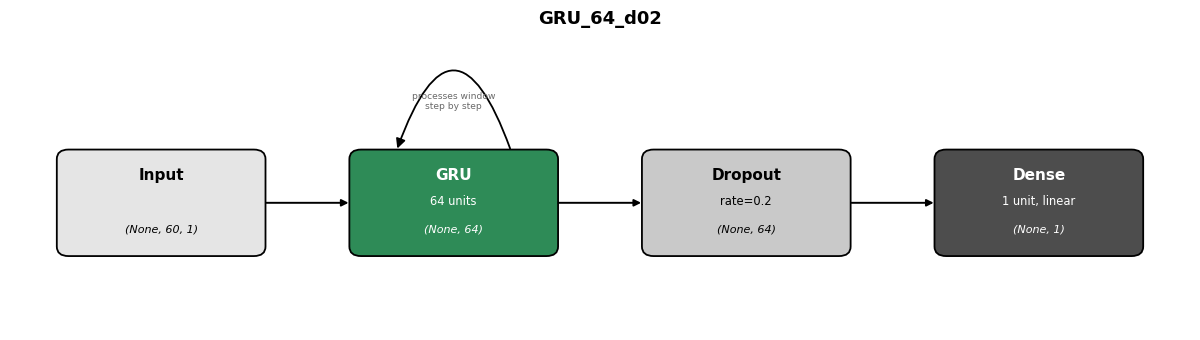


--- Training: GRU_64_d02 ---
Finished in 17.5 seconds, 19 epochs
GRU_64_d02 → Test RMSE: 3.2519 | MAE: 1.8279


3.2518581841011187

In [11]:
# ============================================================
# STEP 11: Model 3, GRU with 64 units (dropout 0.2)
# ============================================================
# Same structure as Model 1 but with a GRU instead of an LSTM;
# this is the direct comparison the brief asks for. A GRU is a
# simplified recurrent unit: it merges the LSTM's three gates into
# two and drops the separate cell state, so at the same width (64
# units) it has noticeably fewer parameters and trains faster.
# The open question this experiment answers: does the LSTM's extra
# capacity actually buy any accuracy on this data?

model_gru_64 = keras.Sequential(name="GRU_64_d02")
model_gru_64.add(keras.layers.Input(shape=(WINDOW_SIZE, 1)))
model_gru_64.add(keras.layers.GRU(64))
model_gru_64.add(keras.layers.Dropout(DROPOUT_RATE))
model_gru_64.add(keras.layers.Dense(1))
model_gru_64.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"],
)
show_architecture(model_gru_64, "arch_GRU_64_d02.png")

model_gru_64, t = train_model(model_gru_64, "GRU_64_d02",
                              X_train, y_train, X_val, y_val)
evaluate_model(model_gru_64, "GRU_64_d02", t, X_test, y_test, base_test)


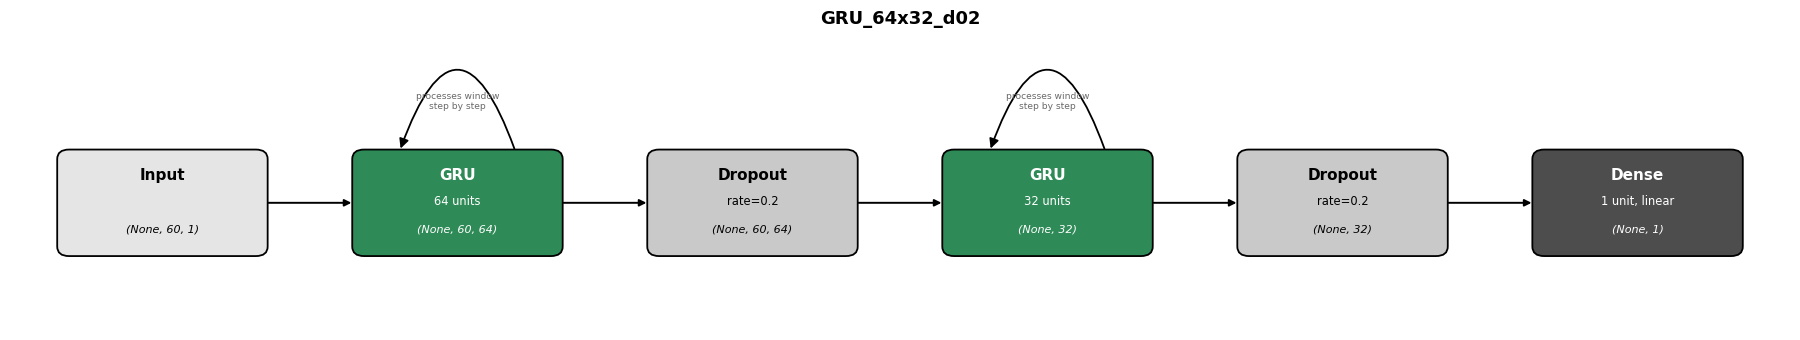


--- Training: GRU_64x32_d02 ---
Finished in 8.9 seconds, 6 epochs
GRU_64x32_d02 → Test RMSE: 3.2422 | MAE: 1.8491


3.2422420602867565

In [12]:
# ============================================================
# STEP 12: Model 4, GRU with 64 then 32 units
# ============================================================
# The two-layer version of the GRU, mirroring Model 2 exactly
# (same depths, same dropout). With all four combinations,
# {LSTM, GRU} x {1 layer, 2 layers}, I can separate the effect
# of the cell type from the effect of depth.

model_gru_64_32 = keras.Sequential(name="GRU_64x32_d02")
model_gru_64_32.add(keras.layers.Input(shape=(WINDOW_SIZE, 1)))
model_gru_64_32.add(keras.layers.GRU(64, return_sequences=True))
model_gru_64_32.add(keras.layers.Dropout(DROPOUT_RATE))
model_gru_64_32.add(keras.layers.GRU(32))
model_gru_64_32.add(keras.layers.Dropout(DROPOUT_RATE))
model_gru_64_32.add(keras.layers.Dense(1))
model_gru_64_32.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"],
)
show_architecture(model_gru_64_32, "arch_GRU_64x32_d02.png")

model_gru_64_32, t = train_model(model_gru_64_32, "GRU_64x32_d02",
                                 X_train, y_train, X_val, y_val)
evaluate_model(model_gru_64_32, "GRU_64x32_d02", t, X_test, y_test, base_test)


### Experiment: dropout ablation

The brief asks us to use dropout to reduce overfitting. But how do I know dropout is actually *doing* anything? The standard way to check is an **ablation**: take the best model, remove the component in question, retrain, and compare.

So the plan is:
1. Pick the best LSTM and the best GRU from the four models above.
2. Rebuild each one **without** dropout and retrain from scratch.
3. Compare the with/without scores.

One important rule I follow throughout: model selection decisions are made on **validation** RMSE, never on test RMSE. The test set must stay untouched by any decision, otherwise the final test scores would be quietly optimistic.


In [13]:
# ============================================================
# STEP 13: Pick best LSTM and GRU (by VALIDATION RMSE only)
# ============================================================
# The evaluate_model() helper scores models on the test set, so I
# cannot use it here; this is a selection decision, and selection
# must only look at validation data. This small function computes
# validation RMSE the same way (predict, convert to USD, RMSE).

def val_rmse_for_model(model):
    """Validation RMSE in USD, for model selection only."""
    pred = model.predict(X_val, verbose=0).flatten()
    pred_usd = (pred + 1.0) * base_val
    true_usd = (y_val + 1.0) * base_val
    return np.sqrt(np.mean((pred_usd - true_usd) ** 2))


def pick_best(models_dict, family_name):
    """Print validation RMSE for each model and return the best one's name."""
    print("Validation RMSE for", family_name, "models:")
    best_name = None
    best_rmse = None
    for name, model in models_dict.items():
        rmse = val_rmse_for_model(model)
        print(" ", name, ":", round(rmse, 4))
        if best_rmse is None or rmse < best_rmse:
            best_rmse = rmse
            best_name = name
    print("Best", family_name, ":", best_name, "\n")
    return best_name


lstm_models = {
    "LSTM_64_d02": model_lstm_64,
    "LSTM_64x32_d02": model_lstm_64_32,
}
gru_models = {
    "GRU_64_d02": model_gru_64,
    "GRU_64x32_d02": model_gru_64_32,
}

best_lstm_name = pick_best(lstm_models, "LSTM")
best_gru_name = pick_best(gru_models, "GRU")

# Keep references to the winning models; I reuse them for the
# ablation below and for the prediction plot at the end.
best_lstm_model = lstm_models[best_lstm_name]
best_gru_model = gru_models[best_gru_name]


Validation RMSE for LSTM models:
  LSTM_64_d02 : 0.8743
  LSTM_64x32_d02 : 0.8738
Best LSTM : LSTM_64x32_d02 

Validation RMSE for GRU models:
  GRU_64_d02 : 0.8734
  GRU_64x32_d02 : 0.8785
Best GRU : GRU_64_d02 



In [14]:
# ============================================================
# STEP 14: Retrain best LSTM without dropout (ablation study)
# ============================================================
# I rebuild whichever LSTM won in STEP 13, with the exact same
# layers except the Dropout layers are removed, and train it from
# scratch. If dropout is genuinely helping generalisation, this
# version should overfit more and score worse on unseen data.
# (Rebuilding from scratch matters: reusing the trained weights
# would not be a fair comparison.)

if best_lstm_name == "LSTM_64_d02":
    model_lstm_no_drop = keras.Sequential(name="LSTM_64_d0")
    model_lstm_no_drop.add(keras.layers.Input(shape=(WINDOW_SIZE, 1)))
    model_lstm_no_drop.add(keras.layers.LSTM(64))
    model_lstm_no_drop.add(keras.layers.Dense(1))
else:
    model_lstm_no_drop = keras.Sequential(name="LSTM_64x32_d0")
    model_lstm_no_drop.add(keras.layers.Input(shape=(WINDOW_SIZE, 1)))
    model_lstm_no_drop.add(keras.layers.LSTM(64, return_sequences=True))
    model_lstm_no_drop.add(keras.layers.LSTM(32))
    model_lstm_no_drop.add(keras.layers.Dense(1))

model_lstm_no_drop.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"],
)

model_lstm_no_drop, t = train_model(model_lstm_no_drop, model_lstm_no_drop.name,
                                    X_train, y_train, X_val, y_val)
evaluate_model(model_lstm_no_drop, model_lstm_no_drop.name, t,
               X_test, y_test, base_test)



--- Training: LSTM_64x32_d0 ---
Finished in 32.4 seconds, 27 epochs
LSTM_64x32_d0 → Test RMSE: 3.2403 | MAE: 1.8247


3.2402790825990015

In [15]:
# ============================================================
# STEP 15: Retrain best GRU without dropout
# ============================================================
# Same ablation as STEP 14, applied to the winning GRU. Running
# the ablation on both cell types shows whether the effect of
# dropout is consistent or architecture-specific.

if best_gru_name == "GRU_64_d02":
    model_gru_no_drop = keras.Sequential(name="GRU_64_d0")
    model_gru_no_drop.add(keras.layers.Input(shape=(WINDOW_SIZE, 1)))
    model_gru_no_drop.add(keras.layers.GRU(64))
    model_gru_no_drop.add(keras.layers.Dense(1))
else:
    model_gru_no_drop = keras.Sequential(name="GRU_64x32_d0")
    model_gru_no_drop.add(keras.layers.Input(shape=(WINDOW_SIZE, 1)))
    model_gru_no_drop.add(keras.layers.GRU(64, return_sequences=True))
    model_gru_no_drop.add(keras.layers.GRU(32))
    model_gru_no_drop.add(keras.layers.Dense(1))

model_gru_no_drop.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"],
)

model_gru_no_drop, t = train_model(model_gru_no_drop, model_gru_no_drop.name,
                                   X_train, y_train, X_val, y_val)
evaluate_model(model_gru_no_drop, model_gru_no_drop.name, t,
               X_test, y_test, base_test)



--- Training: GRU_64_d0 ---
Finished in 18.8 seconds, 23 epochs
GRU_64_d0 → Test RMSE: 3.2627 | MAE: 1.8304


3.262653252822928

### Experiment: window size and learning rate

Two hyperparameter experiments, both starting from the best GRU setup found above:

1. **30-day window instead of 60.** Does the model really need three months of history, or is six weeks enough? A shorter window gives the model less context per prediction, but each sample is smaller so training is faster.
2. **Lower learning rate (0.0001 instead of 0.001).** A smaller learning rate takes smaller optimisation steps: slower, but sometimes it settles into a better minimum.

For the window experiment I have to rebuild the input data from scratch, because the window length changes the shape of every sample.


In [16]:
# ============================================================
# STEP 16: 30-day window experiment (rebuild data with WINDOW=30)
# ============================================================
# Changing the window length changes the shape of every input
# sample, so I rebuild the windows and the split from scratch.
# This is the same procedure as STEP 5 and STEP 6, just with 30
# days instead of 60. The split boundaries (train_end, val_end)
# stay exactly the same, so the model is still tested on the same
# days as everyone else; only the amount of history per
# prediction changes.

WINDOW_30 = 30

# --- Rebuild the sliding windows (same logic as STEP 5) ---
X30_list, y30_list, base30_list = [], [], []
for i in range(len(prices) - WINDOW_30):
    window_prices = prices[i : i + WINDOW_30]
    last_price = window_prices[-1]
    X30_list.append((window_prices / last_price) - 1.0)
    y30_list.append((prices[i + WINDOW_30] / last_price) - 1.0)
    base30_list.append(last_price)

X30 = np.array(X30_list, dtype="float32").reshape(-1, WINDOW_30, 1)
y30 = np.array(y30_list, dtype="float32")
base30 = np.array(base30_list, dtype="float64")

# --- Rebuild the split masks (same logic as STEP 6) ---
tr_m, va_m, te_m = [], [], []
for i in range(len(y30)):
    target_day_index = WINDOW_30 + i
    tr_m.append(target_day_index < train_end)
    va_m.append(train_end <= target_day_index < val_end)
    te_m.append(target_day_index >= val_end)
tr_m, va_m, te_m = np.array(tr_m), np.array(va_m), np.array(te_m)

X_train_30, y_train_30 = X30[tr_m], y30[tr_m]
X_val_30, y_val_30 = X30[va_m], y30[va_m]
X_test_30, y_test_30, base_test_30 = X30[te_m], y30[te_m], base30[te_m]

print("30-day window → train:", len(y_train_30),
      "| val:", len(y_val_30), "| test:", len(y_test_30))

# --- Same architecture as the winning GRU, only the input is shorter ---
model_gru_w30 = keras.Sequential(name="GRU_64_d0_w30")
model_gru_w30.add(keras.layers.Input(shape=(WINDOW_30, 1)))
model_gru_w30.add(keras.layers.GRU(64))
model_gru_w30.add(keras.layers.Dense(1))
model_gru_w30.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"],
)

# The helpers take the data as arguments, so I just pass the
# 30-day arrays here; the 60-day data stays untouched.
model_gru_w30, t = train_model(model_gru_w30, "GRU_64_d0_w30",
                               X_train_30, y_train_30, X_val_30, y_val_30)
evaluate_model(model_gru_w30, "GRU_64_d0_w30", t,
               X_test_30, y_test_30, base_test_30)


30-day window → train: 6906 | val: 1486 | test: 1487

--- Training: GRU_64_d0_w30 ---
Finished in 30.0 seconds, 40 epochs
GRU_64_d0_w30 → Test RMSE: 3.2682 | MAE: 1.8318


3.2681656932590686

In [17]:
# ============================================================
# STEP 17: Lower learning rate experiment (0.0001)
# ============================================================
# Same GRU as before, back on the standard 60-day window, but
# trained with a learning rate 10x smaller than the default.
# Smaller steps make training slower per epoch of progress, but
# early stopping still decides when to stop, so the comparison
# stays fair.

model_gru_lr = keras.Sequential(name="GRU_64_d0_lr1e-4")
model_gru_lr.add(keras.layers.Input(shape=(WINDOW_SIZE, 1)))
model_gru_lr.add(keras.layers.GRU(64))
model_gru_lr.add(keras.layers.Dense(1))
model_gru_lr.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # 10x lower than default
    loss="mse",
    metrics=["mae"],
)

model_gru_lr, t = train_model(model_gru_lr, "GRU_64_d0_lr1e-4",
                              X_train, y_train, X_val, y_val)
evaluate_model(model_gru_lr, "GRU_64_d0_lr1e-4", t, X_test, y_test, base_test)



--- Training: GRU_64_d0_lr1e-4 ---
Finished in 5.7 seconds, 6 epochs
GRU_64_d0_lr1e-4 → Test RMSE: 3.2385 | MAE: 1.8249


3.238478245711444

### My extension: CNN-LSTM hybrid model

This goes beyond the brief. The idea is a division of labour between two layer types:

- A **1D convolution** slides a small filter (3 days wide) along the window and learns to detect short local patterns: small bumps, dips, reversals.
- **Max pooling** then halves the sequence length, keeping the strongest signal from each pair of days.
- The **LSTM** reads this shorter, feature-rich sequence and models the longer-term trend.

So the CNN acts as a learned pre-processor for the LSTM. Recent stock prediction papers report that this kind of hybrid often beats standalone recurrent models (see report references), and I wanted to test that claim under exactly the same protocol as my LSTM and GRU experiments.


Model: "CNN32k3_LSTM64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 60, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,025 (97.75 KB)

 Trainable params: 25,025 (97.75 KB)

 Non-trainable params: 0 (0.00 B)

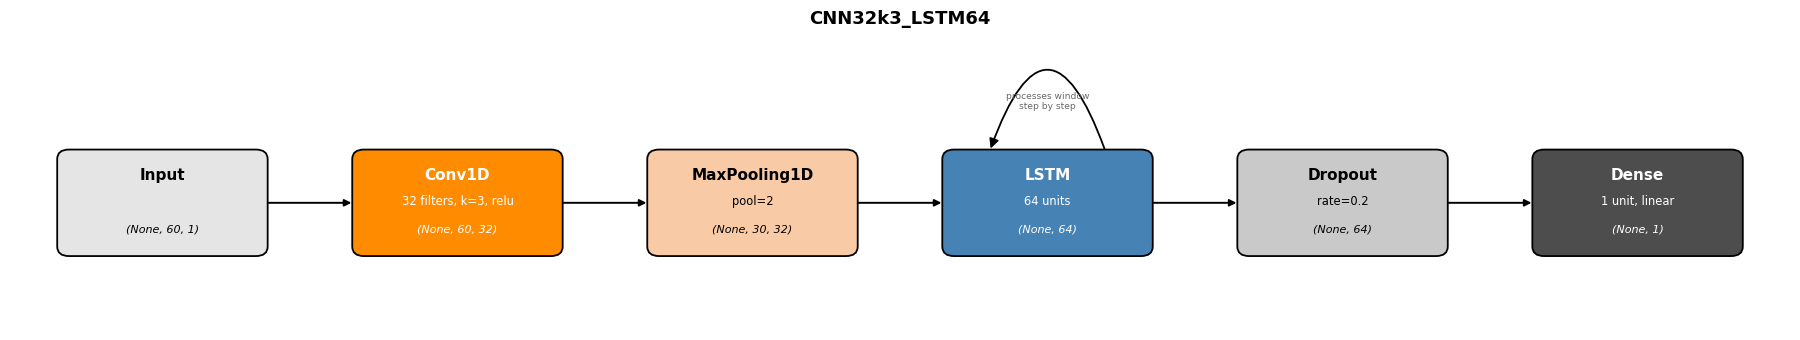


--- Training: CNN32k3_LSTM64 ---
Finished in 24.3 seconds, 26 epochs
CNN32k3_LSTM64 → Test RMSE: 3.2278 | MAE: 1.8237


3.2277974204181197

In [18]:
# ============================================================
# STEP 18: CNN-LSTM hybrid model
# ============================================================
# Name decoded: CNN with 32 filters and kernel size 3, feeding an
# LSTM with 64 units. Data flow through the model:
#   (60 days, 1 feature)
#     → Conv1D        → (60 days, 32 features)  local patterns
#     → MaxPooling1D  → (30 days, 32 features)  halve the length
#     → LSTM(64)      → (64,)                   long-term summary
#     → Dropout, Dense(1) → predicted relative change

model_cnn_lstm = keras.Sequential(name="CNN32k3_LSTM64")
model_cnn_lstm.add(keras.layers.Input(shape=(WINDOW_SIZE, 1)))

# Conv1D: 32 filters, each 3 days wide, ReLU activation.
# padding='causal' is important for time series: each output only
# depends on the current day and earlier days, never on future days,
# so the convolution cannot leak future information.
model_cnn_lstm.add(keras.layers.Conv1D(filters=32, kernel_size=3,
                                       activation="relu", padding="causal"))

# Pooling halves the sequence (60 → 30 steps), keeping the strongest
# response in each pair. The LSTM then has a shorter sequence to read.
model_cnn_lstm.add(keras.layers.MaxPooling1D(pool_size=2))

# Same recurrent "head" as my plain LSTM model, for a fair comparison:
# any performance difference comes from the CNN front-end.
model_cnn_lstm.add(keras.layers.LSTM(64))
model_cnn_lstm.add(keras.layers.Dropout(DROPOUT_RATE))
model_cnn_lstm.add(keras.layers.Dense(1))

model_cnn_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"],
)

# Print the layer table; this model has a more interesting structure,
# so the summary and diagram are both worth showing in the appendix.
model_cnn_lstm.summary()
show_architecture(model_cnn_lstm, "arch_CNN32k3_LSTM64.png")

model_cnn_lstm, t = train_model(model_cnn_lstm, "CNN32k3_LSTM64",
                                X_train, y_train, X_val, y_val)
evaluate_model(model_cnn_lstm, "CNN32k3_LSTM64", t, X_test, y_test, base_test)


### Fine-tuning (brief requirement)

The brief mentions fine-tuning as a way to improve generalisation. The idea: after normal training has found a good region of the weight space, continue training with a **much smaller learning rate** so the optimiser can settle more precisely into the minimum instead of stepping over it.

I take the already-trained CNN-LSTM (my best model so far), divide its learning rate by 10, and let it train a little longer; early stopping again decides when to stop.


In [19]:
# ============================================================
# STEP 19: Fine-tune the CNN-LSTM at a lower learning rate
# ============================================================
# Unlike every other training run in this notebook, this one does
# NOT start from fresh random weights; that is the whole point of
# fine-tuning. I keep the trained weights and only turn the
# learning rate down by a factor of 10.

current_lr = float(model_cnn_lstm.optimizer.learning_rate.numpy())
new_lr = current_lr / 10
model_cnn_lstm.optimizer.learning_rate.assign(new_lr)
print("Fine-tuning with learning rate:", new_lr)

# train_model() resets the seed, but that only affects batch
# shuffling here; the weights carry over from STEP 18.
model_cnn_lstm, t = train_model(model_cnn_lstm, "CNN32k3_LSTM64_finetuned",
                                X_train, y_train, X_val, y_val)
evaluate_model(model_cnn_lstm, "CNN32k3_LSTM64_finetuned", t,
               X_test, y_test, base_test)


Fine-tuning with learning rate: 0.00010000000474974513

--- Training: CNN32k3_LSTM64_finetuned ---
Finished in 22.0 seconds, 24 epochs
CNN32k3_LSTM64_finetuned → Test RMSE: 3.2213 | MAE: 1.8253


3.2213498926780595

In [20]:
# ============================================================
# STEP 20: Results table, all models compared
# ============================================================
# Every call to evaluate_model() (and the baseline in STEP 7)
# appended one row to all_results. Now I turn that list into a
# single table, sorted so the most accurate model is at the top.
# This table is the source for the results section of my report.

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("Test RMSE").reset_index(drop=True)

print("\n=== FINAL RESULTS (sorted by Test RMSE) ===")
display_cols = ["Model", "Test RMSE", "Test MAE", "Test MAPE %",
                "Parameters", "Train time (s)"]
print(results_df[display_cols].to_string(index=False))

# Save as CSV so the numbers can be checked and reused without
# re-running six model trainings.
results_df.to_csv(OUTPUT_FOLDER + "/tables/results_all_runs.csv", index=False)
print("\nSaved to", OUTPUT_FOLDER + "/tables/results_all_runs.csv")
results_df



=== FINAL RESULTS (sorted by Test RMSE) ===
                   Model  Test RMSE  Test MAE  Test MAPE %  Parameters  Train time (s)
CNN32k3_LSTM64_finetuned   3.221350  1.825259     1.160609     25025.0            22.0
          CNN32k3_LSTM64   3.227797  1.823723     1.158574     25025.0            24.3
  Baseline (persistence)   3.238027  1.826946     1.158924         NaN             NaN
        GRU_64_d0_lr1e-4   3.238478  1.824873     1.157724     12929.0             5.7
           LSTM_64x32_d0   3.240279  1.824716     1.158215     29345.0            32.4
           GRU_64x32_d02   3.242242  1.849069     1.173380     22305.0             8.9
          LSTM_64x32_d02   3.242739  1.825156     1.158527     29345.0            20.0
             LSTM_64_d02   3.248561  1.828129     1.160686     16961.0            18.8
              GRU_64_d02   3.251858  1.827938     1.159679     12929.0            17.5
               GRU_64_d0   3.262653  1.830440     1.160999     12929.0            18.

,Model,Test RMSE,Test MAE,Test MAPE %,Parameters,Train time (s)
0,CNN32k3_LSTM64_finetuned,3.221350,1.825259,1.160609,25025.0,22.0
1,CNN32k3_LSTM64,3.227797,1.823723,1.158574,25025.0,24.3
2,Baseline (persistence),3.238027,1.826946,1.158924,NaN,NaN
3,GRU_64_d0_lr1e-4,3.238478,1.824873,1.157724,12929.0,5.7
4,LSTM_64x32_d0,3.240279,1.824716,1.158215,29345.0,32.4
5,GRU_64x32_d02,3.242242,1.849069,1.173380,22305.0,8.9
6,LSTM_64x32_d02,3.242739,1.825156,1.158527,29345.0,20.0
7,LSTM_64_d02,3.248561,1.828129,1.160686,16961.0,18.8
8,GRU_64_d02,3.251858,1.827938,1.159679,12929.0,17.5
9,GRU_64_d0,3.262653,1.830440,1.160999,12929.0,18.8


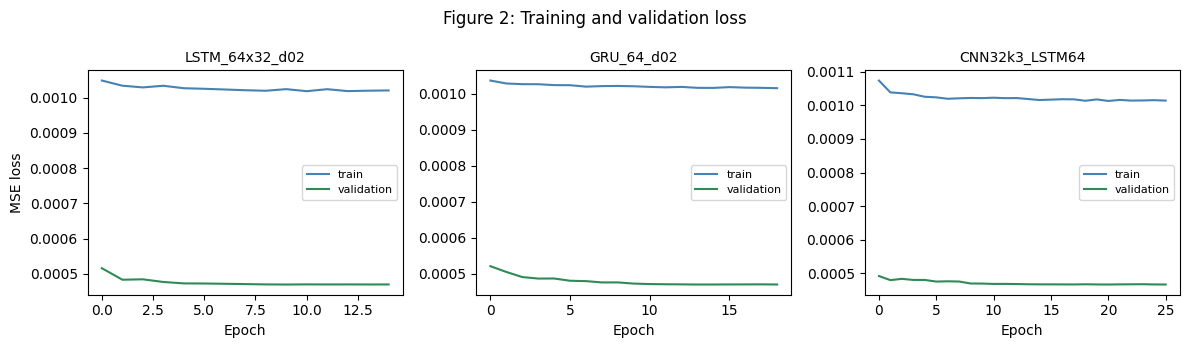

In [21]:
# ============================================================
# STEP 21: Plot of training loss curves for main models
# ============================================================
# These curves show HOW each model trained, not just the final
# score. What to look for:
#   - both curves falling together  → healthy learning
#   - train falling, validation rising → overfitting
#   - the gap between the curves    → how much the model memorises
# Early stopping cut each run where validation loss stopped
# improving, so the curves end at different epochs.

models_to_plot = ["LSTM_64x32_d02", "GRU_64_d02", "CNN32k3_LSTM64"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, name in zip(axes, models_to_plot):
    history = training_histories[name]
    ax.plot(history["loss"], label="train", color="steelblue")
    ax.plot(history["val_loss"], label="validation", color="seagreen")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)

axes[0].set_ylabel("MSE loss")
fig.suptitle("Figure 2: Training and validation loss")
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + "/figures/fig2_loss_curves.png")
plt.show()


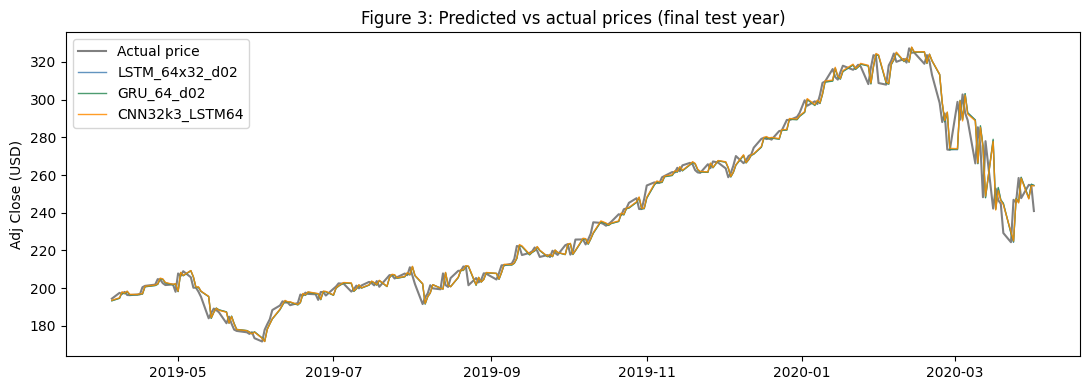

In [22]:
# ============================================================
# STEP 22: Plot of predictions vs actual (last year of test set)
# ============================================================
# A visual sanity check of what the metrics mean in practice.
# I plot the best LSTM, best GRU and the hybrid against the actual
# price. Only the last 250 trading days (~1 year) are shown;
# plotting all 1,400+ test days makes the lines unreadable.
# This period includes the March 2020 crash, which is a good
# stress test for the models.

# Dates for the test period (the target day of each test sample)
test_dates = dates[val_end : val_end + len(y_test)]
actual_usd = (y_test + 1.0) * base_test

n_show = 250
plot_slice = slice(-n_show, None)

plt.figure(figsize=(11, 4))
plt.plot(test_dates[plot_slice], actual_usd[plot_slice],
         color="gray", linewidth=1.5, label="Actual price")

# Predict with each headline model and convert back to USD,
# exactly as in evaluate_model().
for model, colour, label in [
    (best_lstm_model, "steelblue", best_lstm_name),
    (best_gru_model, "seagreen", best_gru_name),
    (model_cnn_lstm, "darkorange", "CNN32k3_LSTM64"),
]:
    pred_rel = model.predict(X_test, verbose=0).flatten()
    pred_usd = (pred_rel + 1.0) * base_test
    plt.plot(test_dates[plot_slice], pred_usd[plot_slice],
             color=colour, linewidth=1, alpha=0.85, label=label)

plt.ylabel("Adj Close (USD)")
plt.title("Figure 3: Predicted vs actual prices (final test year)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + "/figures/fig3_predictions_vs_actual.png")
plt.show()

# Note for the report: the predictions hug the actual line closely.
# That LOOKS impressive, but it is mostly the persistence effect;
# predicting something near yesterday's price is already very close.
# The metrics table above is the honest comparison.


In [23]:
# ============================================================
# STEP 23: Save model summaries for the report appendix
# ============================================================
# Keras can redirect its summary() printout line by line, so I
# write the layer tables of the three headline models to one text
# file. That goes in the appendix as evidence of the architectures.

with open(OUTPUT_FOLDER + "/models/model_summaries.txt", "w") as f:
    for m in [best_lstm_model, best_gru_model, model_cnn_lstm]:
        m.summary(print_fn=lambda line: f.write(line + "\n"))
        f.write("\n" + "=" * 60 + "\n\n")

print("Model summaries saved.")

# Final recap of the headline models and the number to beat
print("\nBest LSTM:", best_lstm_name)
print("Best GRU :", best_gru_name)
print("Extension:", "CNN32k3_LSTM64")
print("Baseline Test RMSE:", round(baseline_rmse, 4))


Model summaries saved.

Best LSTM: LSTM_64x32_d02
Best GRU : GRU_64_d02
Extension: CNN32k3_LSTM64
Baseline Test RMSE: 3.238


In [28]:
# ============================================================
# STEP 24: Short conclusion from the comparisons above
# ============================================================
# I compute this summary from the actual results table, so it stays
# correct even if the notebook is rerun and the numbers move slightly.

overall_best = results_df.iloc[0]
beats_baseline = overall_best["Test RMSE"] < baseline_rmse
gap_vs_baseline_pct = (overall_best["Test RMSE"] / baseline_rmse - 1) * 100

# Recompute the validation RMSE of the two winning models from STEP 13
# (val_rmse_for_model is still in scope from that cell).
best_lstm_val = val_rmse_for_model(best_lstm_model)
best_gru_val = val_rmse_for_model(best_gru_model)
lstm_gru_gap_pct = (best_gru_val / best_lstm_val - 1) * 100
cheaper_model = "GRU" if best_gru_model.count_params() < best_lstm_model.count_params() else "LSTM"

print("=== CONCLUSION ===")
print(f"Best overall model : {overall_best['Model']} "
      f"(test RMSE {overall_best['Test RMSE']:.4f} USD)")
print(f"Persistence baseline: {baseline_rmse:.4f} USD")
if beats_baseline:
    print(f"-> The best model beats the baseline by {abs(gap_vs_baseline_pct):.2f}%. "
          "A small edge, and it should not be overstated.")
else:
    print(f"-> The best model is {abs(gap_vs_baseline_pct):.2f}% WORSE than the baseline. "
          "None of my models reliably beat 'tomorrow = today' on this data.")

print(f"\nLSTM vs GRU (validation RMSE): \nbest LSTM {best_lstm_name} ({best_lstm_val:.4f}), \n"
      f"best GRU {best_gru_name} ({best_gru_val:.4f}), a {abs(lstm_gru_gap_pct):.2f}% difference. \n"
      f"{cheaper_model} uses fewer parameters, so it is the more efficient choice at similar accuracy.")

print("\nCNN-LSTM extension: adding a convolution front-end to the LSTM "
      f"{'improved' if results_df.loc[results_df['Model'].str.contains('CNN'), 'Test RMSE'].min() < results_df.loc[results_df['Model'] == best_lstm_name, 'Test RMSE'].values[0] else 'did not clearly improve'} "
      "on the plain LSTM under the same training protocol.")

print("\nAll numbers above come from this notebook's own results table. "
      "I did not copy any result from elsewhere.")


=== CONCLUSION ===
Best overall model : CNN32k3_LSTM64_finetuned (test RMSE 3.2213 USD)
Persistence baseline: 3.2380 USD
-> The best model beats the baseline by 0.52%. A small edge, and it should not be overstated.

LSTM vs GRU (validation RMSE): 
best LSTM LSTM_64x32_d02 (0.8738), 
best GRU GRU_64_d02 (0.8734), a 0.04% difference. 
GRU uses fewer parameters, so it is the more efficient choice at similar accuracy.

CNN-LSTM extension: adding a convolution front-end to the LSTM improved on the plain LSTM under the same training protocol.

All numbers above come from this notebook's own results table. I did not copy any result from elsewhere.


In [25]:
import shutil
import os

# Define the output folder (already defined in the notebook, but for clarity)
# OUTPUT_FOLDER = "outputs_student"

# Define the base name for the archive and the root directory to archive
archive_name = os.path.join("/content", OUTPUT_FOLDER)
root_dir = OUTPUT_FOLDER

# Create the zip archive
shutil.make_archive(archive_name, 'zip', root_dir)

print(f"Created zip file: {archive_name}.zip")

Created zip file: /content/outputs_student.zip
